# Overview

In [1]:
import os
print(os.listdir('.'))

['eda.html', 'eda.ipynb']


- The dataset contains 284,807 transactions, which is nearly 285,000 credit card purchases
- There are 31 columns(pieces of information) per transaction.
- The columns are Time, Amount, Class and 28 anaonymised columns named V1 through V28.
- Time: How many seconds elepsed since the first transaction in the dataset(a kind of timestamp)
- Amount: how much money was involved in the transaction
- Class: the answer column:0 = legitimate transaction, 1 = fraud
- The 28 columns named V1-V28 are security signals. They are deliberately scrambled(using a technique called PCA) to protect customer privacy, so we can't read them directly. but they carry patterns that machine learning model can learn from.


In [2]:
import pandas as pd

data = pd.read_csv(r'C:\Users\gikon\Downloads\7 day - AI Challenge\my-ml-project\data\creditcard.csv')
print(f"Shape of the dataset: {data.shape}")
print(f"Columns: {data.columns.tolist()}")
print(f"Data types:\n{data.dtypes}")
data.head()

Shape of the dataset: (284807, 31)
Columns: ['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount', 'Class']
Data types:
Time      float64
V1        float64
V2        float64
V3        float64
V4        float64
V5        float64
V6        float64
V7        float64
V8        float64
V9        float64
V10       float64
V11       float64
V12       float64
V13       float64
V14       float64
V15       float64
V16       float64
V17       float64
V18       float64
V19       float64
V20       float64
V21       float64
V22       float64
V23       float64
V24       float64
V25       float64
V26       float64
V27       float64
V28       float64
Amount    float64
Class       int64
dtype: object


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


# Target Analysis

In [3]:
#!pip install seaborn

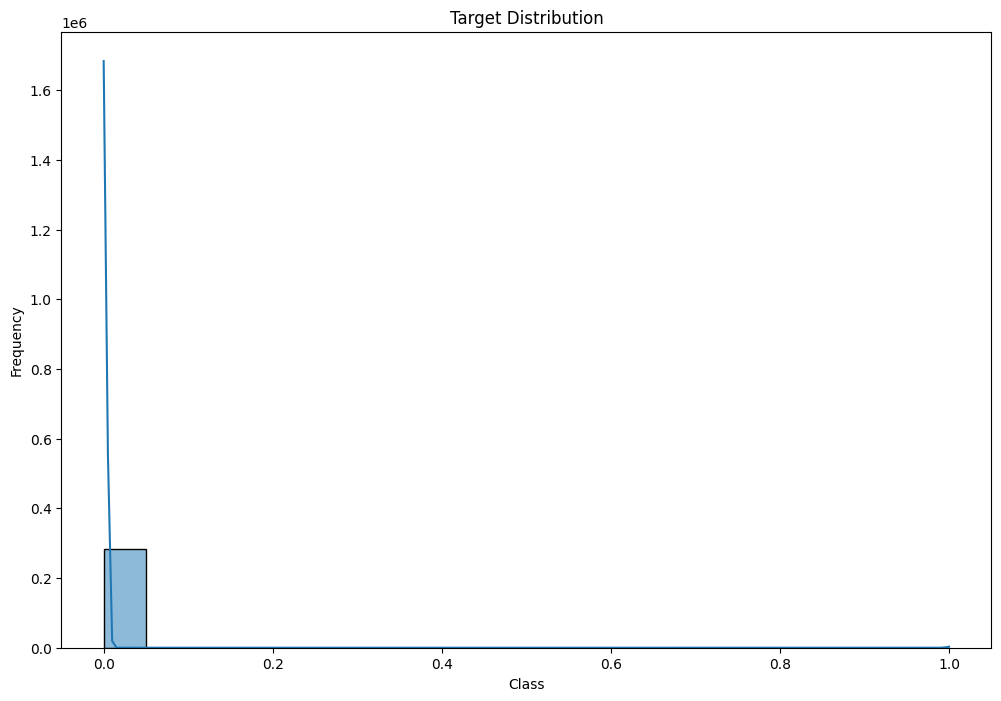

count    284807.000000
mean          0.001727
std           0.041527
min           0.000000
25%           0.000000
50%           0.000000
75%           0.000000
max           1.000000
Name: Class, dtype: float64


In [4]:
import matplotlib.pyplot as plt
import seaborn as sns

target_col = 'Class'  # target column name

if pd.api.types.is_numeric_dtype(data[target_col]):  # Regression
    plt.figure(figsize=(12, 8))
    sns.histplot(data[target_col], kde=True)
    plt.title('Target Distribution')
    plt.xlabel('Class')
    plt.ylabel('Frequency')
    plt.show()
    
    print(data[target_col].describe())
else:  # Classification
    plt.figure(figsize=(12, 8))
    sns.countplot(x=target_col, data=data)
    plt.title('Target Class Distribution')
    plt.xlabel('Class')
    plt.ylabel('Count')
    plt.show()

- The section shows how much fraud is in the data. The chart shows how many transactions are fraudulent  vs. legitimate, along with summary statistics.
- The mean of 0.001727 means that 0.17% of transactions are fraudulent, roughly 492 fraud cases out of 284807 total.
- The std which stands for the standard deviation measures how spread out the values in a column are from the avaerage(mean), but in our cas the target column which is 'Class' is not a continuous number like transaction amount but a binary which is either each transaction is either legitimate(0) or a 1 (fraud). In our case since almost every transaction is legitimate(0) and only a handful are fraud(1) the values barely move away from 0. This also confirms our earlier finding that fraud is extremely rare. 
- This also reflect on why the 25th, 50th, and 75th percentiles are all zero showing you have to go past the 99.8% of all transactions before you encountered any fraudulent transactions.
- *Hypothetically if the fraud transactions were 50% of the transactions, the std would be much closer to 0.5.*
- 
- From the chart there is a massive spike at 0(legitimate) and a timy barely-visisble bar at 1(fraud). The fraudulent transactions are nearly invisisble next to the volume of normal transactions.
- This interprets to every 1000 transactions, fewer than 2 are fraudulent. 
- This is a highly imbalanced dataset, the two groups are extremely unequal in size. This is an important finding since if a model said "every transactions is legitimate" it would be right 99.83% of the time, but completely useless at detecting fraud. Every model must be built carefully to handle this imbalance, other wise it will look accurate on paper but fail in practise which might translate to business losses. 


# Missing Values

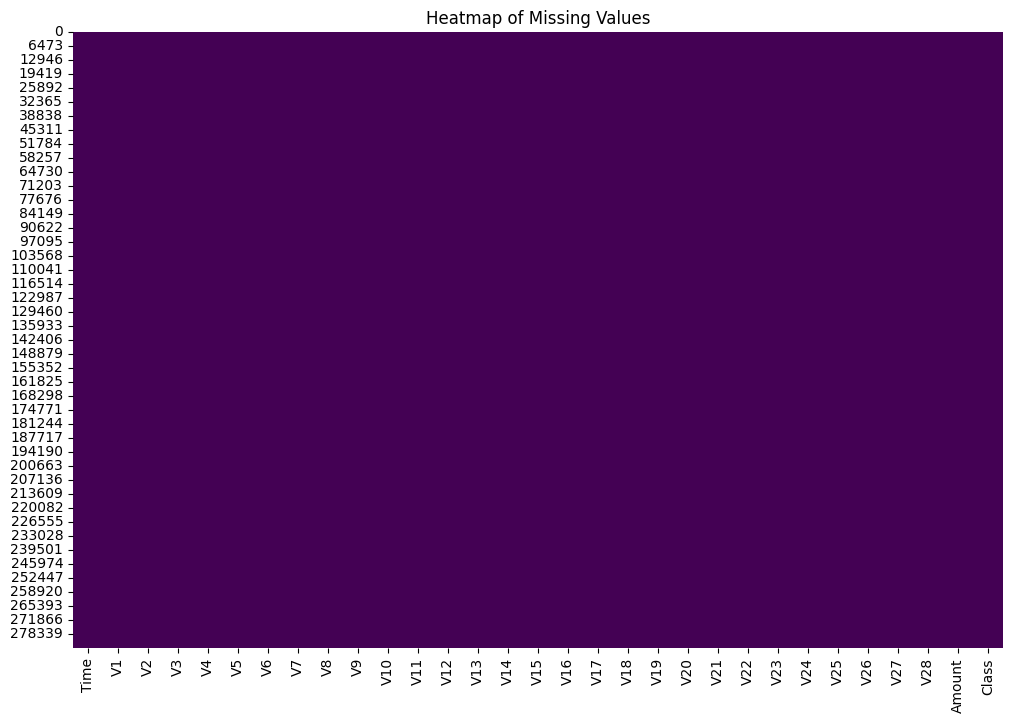

In [19]:
plt.figure(figsize=(12, 8))
sns.heatmap(data.isnull(), cbar=False, cmap='viridis')
plt.title('Heatmap of Missing Values')
plt.show()

- The heatmap represents the missing data across 285,000 rows and 31 columns. Yellow = missing, daqrk = present.  The heatmap is uniformly dark not a single yellow syttreak anywhere. 
- These intereprets to that every  transaction has a value for every single column.
- This is great news since missing data is the most common form of headaches in data projects.


# Feature Distributions

C:\Users\gikon\AppData\Local\Temp\ipykernel_15956\862442422.py:15: UserWarning: Tight layout not applied. tight_layout cannot make Axes height small enough to accommodate all Axes decorations.
  plt.tight_layout()


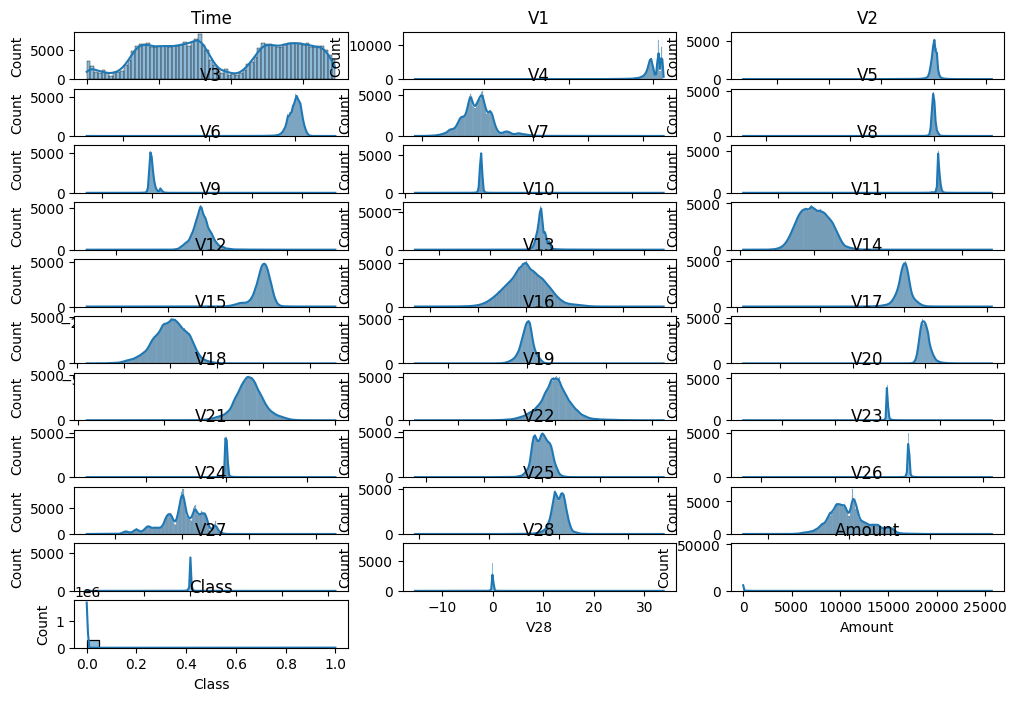

In [20]:
numeric_features = data.select_dtypes(include=['number']).columns
num_plots = len(numeric_features)
rows = (num_plots // 3) + (num_plots % 3 > 0)

fig, axes = plt.subplots(rows, 3, figsize=(12, 8))
axes = axes.flatten()

for i, col in enumerate(numeric_features):
    sns.histplot(data[col], ax=axes[i], kde=True)
    axes[i].set_title(col)

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

- V1–V28: Almost all of these anonymised security signals follow a bell-curve shape (technically called a normal distribution) — most values cluster around zero, tapering off on both sides. This is expected because of how the data was mathematically transformed. A few (like V27, V28) are more tightly peaked or have slight irregularities.


- Amount: This distribution is strongly right-skewed — the vast majority of transactions are small (clustered near zero), but a long tail stretches to the right, showing some very large transactions. Most purchases are modest; a few are very large.

*The amount column confirms that most fraudulent activity(when it occurs) tends to involve transactions of varying sizes, although the distribution is worth noting for modelling. The time pattern tells us this is a real world data with natuaral daily rhythms.*


-  Time: The time column shows a bimodal pattern (two humps) — suggesting the data spans roughly two days, with transaction volume dipping overnight and rising during daytime hours.

- Class: An overwhelming spike at 0, with fraud barely visible

# Correlation Matrix

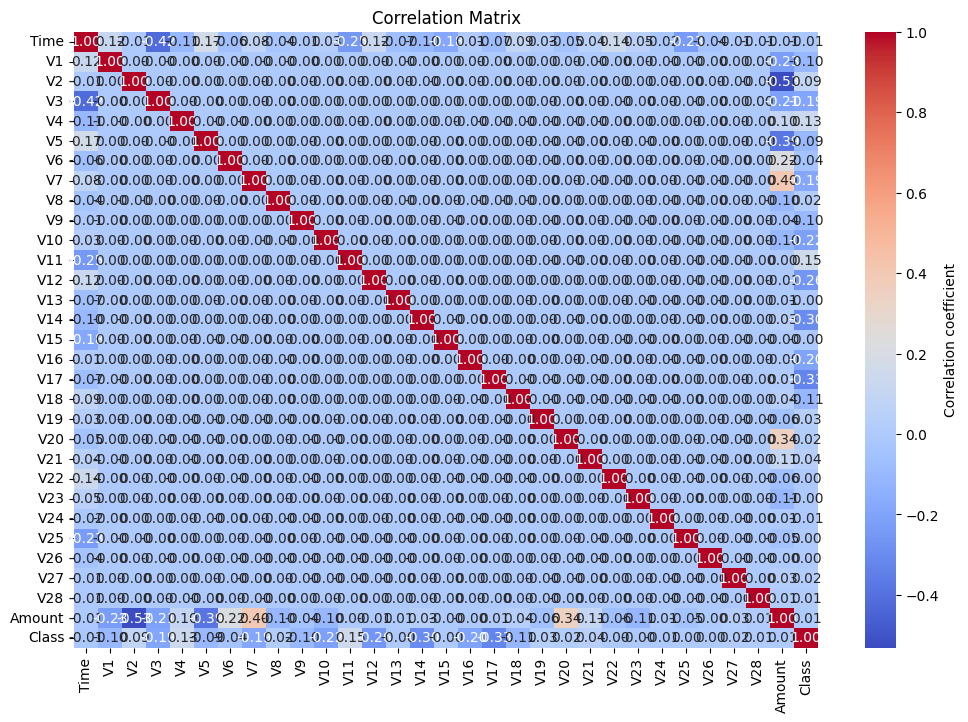

In [21]:
plt.figure(figsize=(12, 8))
corr_matrix = data.corr()
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', cbar_kws={'label': 'Correlation coefficient'})
plt.title('Correlation Matrix')
plt.show()

The heatmap shows how strongly every column relates to every other column. 
Red = strong positive relationship
Blue = strong negative relationship
White = no relationship

The map represent which signals relate to fraud.

1. Class Column (The most important one): V17 (−0.33), V14 (−0.30), and V12 (−0.26) are the three strongest predictors of fraud, and they are all negative, meaning when these signals drop to very low values, fraud becomes significantly more likely. V10 and V16 are secondary signals. Everything else, including the transaction Amount and Time, contributes very little on its own.

2. Amount Column: Amount correlates with V2 (+0.59), V4 (−0.53), V5 (−0.40), and V7 (−0.47) — these are moderate to strong relationships. This tells you those PCA components captured some of the transaction size signal when the data was transformed.
Amount's correlation with Class is only +0.06 — confirming that large transactions are not a reliable fraud indicator by themselves. Fraudsters operate across all transaction sizes.

3. Time Column: Time has some mild correlations with a few V columns (notably V3 at −0.40), suggesting that some of the PCA signals vary across the time of day. However, Time's correlation with Class (fraud) is essentially −0.01 — time of transaction is not a useful fraud predictor in this dataset.

4. V column Cross-Correlations(The body of the Matrix): The vast body of the matrix — V1 through V28 against each other — is almost entirely white (near zero). This is by design. PCA was specifically constructed to make the V columns independent of one another. A few notable exceptions:

V2 and V5: −0.36 — a mild negative relationship between these two components
V3 and V7: mild relationship — some overlap in what these capture
Amount vs V2/V4/V5/V7 as noted above

But these are minor. The overwhelming story is that the V columns carry different, non-overlapping information — which is exactly what you want in a machine learning model. Redundant features add noise; independent features add power.


## Summary

1. V17, V14, and V12 are your headline predictors. They have the strongest (negative) correlation with fraud. When building a model, these three features will likely be among the most important inputs.
2. Amount is a weak predictor on its own. Despite being the most intuitive fraud signal ("large purchase = suspicious"), the data shows fraud does not strongly favour high-value transactions. A model that relies heavily on Amount will underperform.
3. Most V columns are uncorrelated with each other. This is ideal — each one contributes something unique. The model will benefit from using all of them rather than dropping many, because they are not telling the same story twice.




# Features vs Target

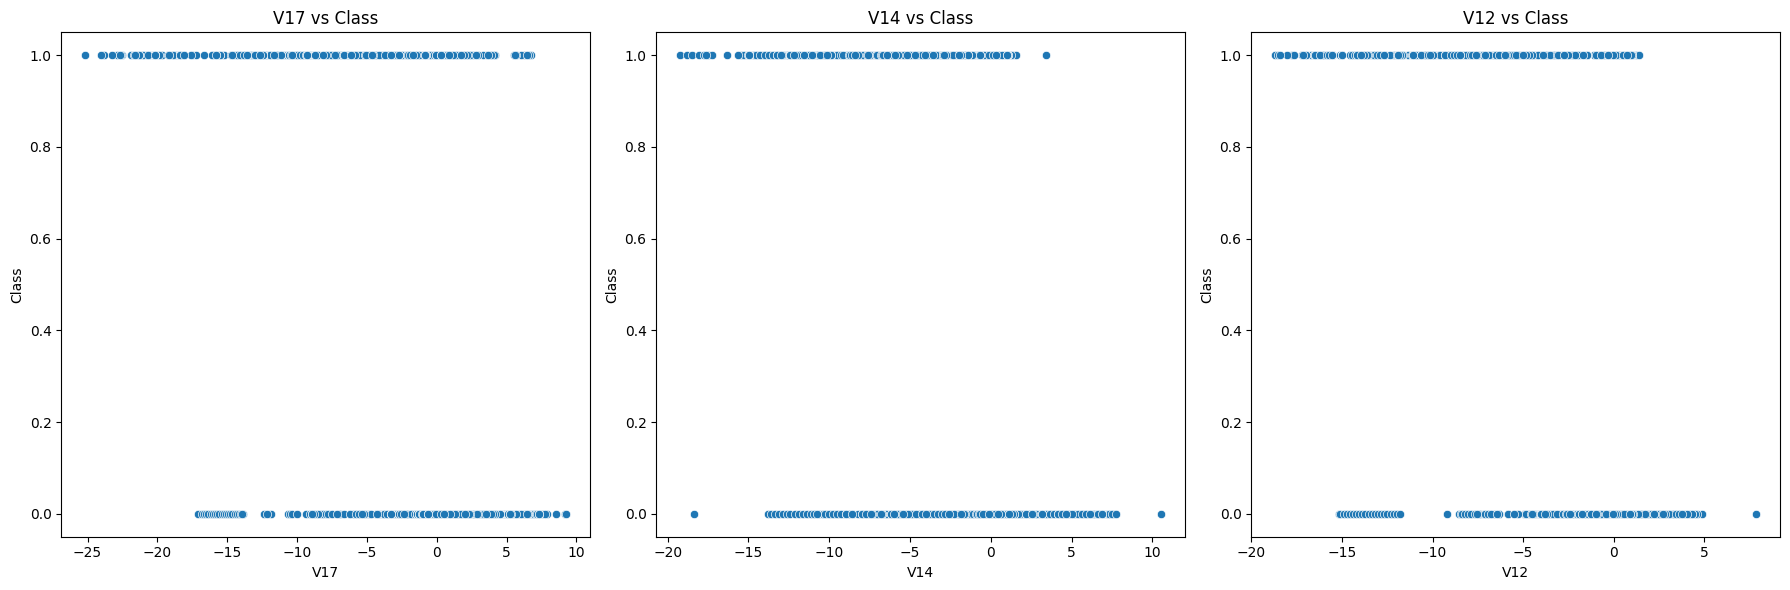

In [22]:
strong_corr_features = corr_matrix[target_col].abs().sort_values(ascending=False).index[1:4]

if pd.api.types.is_numeric_dtype(data[target_col]):  # Regression
    fig, axes = plt.subplots(1, 3, figsize=(18, 6))
    for i, col in enumerate(strong_corr_features):
        sns.scatterplot(x=data[col], y=data[target_col], ax=axes[i])
        axes[i].set_title(f'{col} vs {target_col}')
        axes[i].set_xlabel(col)
        axes[i].set_ylabel(target_col)
else:  # Classification
    fig, axes = plt.subplots(1, 3, figsize=(18, 6))
    for i, col in enumerate(strong_corr_features):
        sns.boxplot(x=data[target_col], y=data[col], ax=axes[i])
        axes[i].set_title(f'{col} vs {target_col}')
        axes[i].set_xlabel('Class')
        axes[i].set_ylabel(col)

plt.tight_layout()
plt.show()

- This is the visualisation of the best predictors

- It identifies the 3 columns most correlated with fraud (V17, V14, V12) and plotted scatter charts of each one against the Class column (0 = legitimate, 1 = fraud)
- All three charts show two horizontal bands of dots — one at y=0 (legitimate) and one at y=1 (fraud). The key observation is:

Fraud transactions (y=1) cluster in a specific range of values on the x-axis, particularly at very negative values (left side of the chart).
Legitimate transactions (y=0) are spread more broadly across the x-axis.

In other words: when V17, V14, or V12 shows a very low (negative) number, fraud is much more likely.

- These three signals are essentially "red flags." If a transaction comes in and V14 reads −18 or V17 reads −25, that pattern almost never occurs in normal transactions, but does appear repeatedly in confirmed fraud cases. A machine learning model will learn exactly these kinds of cut-off patterns to flag suspicious transactions automatically.


# Key Findings

Exploratory Data Analysis
Dataset: 284,807 transactions × 31 features. All features are numeric (float64/int64). No missing values across any column. Target variable (Class) is binary: 0 = legitimate, 1 = fraud. Data is complete, well-structured, and ready for modelling with no cleaning or gap-filling required.
Key Findings:

1. Severe class imbalance — only 492 fraud cases (0.17%) vs. 284,315 legitimate transactions (a 579:1 ratio). Standard accuracy metrics will be misleading; requires SMOTE, undersampling, or class weighting before modelling. Evaluate using F1-score and AUC-ROC.

2. V17, V14, and V12 are the strongest fraud predictors — correlation coefficients of −0.33, −0.30, and −0.26 with Class respectively. Fraudulent transactions cluster at strongly negative values of these features, providing clear statistical separation.

3. V1–V28 are mutually independent by PCA design — near-zero inter-feature correlation throughout. No redundant features to drop; all 28 carry distinct, non-overlapping signal.

4. Amount is a weak standalone predictor (r = +0.06) — transaction size alone does not reliably flag fraud and should not be used as a primary signal.

5. Time has negligible predictive value (r = −0.01 with Class) — despite showing a bimodal daily distribution, it contributes little to fraud detection.

Notable observations affecting modelling:

Amount is heavily right-skewed, apply log transform before scaling.
Class imbalance is extreme, a naïve model predicting "legitimate" for every transaction scores 99.83% accuracy while catching zero fraud cases. Oversampling or class weighting is essential before training.
